# Evaluate a pretrained checkpoint

This notebook evaluates every generated benchmark in one category. The model is loaded once, while each benchmark can receive its own detailed JSON report. The primary score is macro bidirectional accuracy: each matched context-target pair must win both the same-target context comparison and the length-normalized same-context target comparison.

The category score is the unweighted mean of the primary scores of its benchmarks, so every benchmark has equal weight regardless of its number or size of contrast sets.

In [5]:
MODEL_CHECKPOINT = "../../models/35m_balanced_1b5.pt"
TOKENIZER = "../../src/tokenizer/production_16k/tokenizer.model"

BATCH_SIZE = 32
DEVICE = "auto"  # one of: auto, cpu, cuda
SAVE_DETAILED_REPORTS = True

In [6]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import sentencepiece as spm
from IPython.display import Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "src" / "evaluation"
        ).is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find the pavullmo repository root from the current directory"
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
EVALUATION_DIR = PROJECT_ROOT / "src" / "evaluation"
NOTEBOOK_DIR = EVALUATION_DIR
BENCHMARKS_DIR = EVALUATION_DIR / "benchmarks"

if str(EVALUATION_DIR) not in sys.path:
    sys.path.insert(0, str(EVALUATION_DIR))

import score_synthetic_benchmark as scorer


def resolve_input_path(value: str | Path) -> Path:
    path = Path(value).expanduser()
    if path.is_absolute():
        return path.resolve()

    candidates = (Path.cwd() / path, NOTEBOOK_DIR / path, PROJECT_ROOT / path)
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return candidates[0].resolve()


def get_benches_by_category(src: Path) -> dict[str, list[Path]]:
    return {
        directory.name: sorted(directory.glob("*-bench.json"))
        for directory in sorted(src.iterdir())
        if directory.is_dir()
    }


benchmarks = get_benches_by_category(BENCHMARKS_DIR / "benches")
available_categories = {name: len(paths) for name, paths in benchmarks.items()}
print(f"Project root: {PROJECT_ROOT}")
print(f"Available categories: {available_categories}")

Project root: /home/samuele/Desktop/pavullmo
Available categories: {'icl': 5, 'knowledge': 5, 'language-manipulation': 5, 'math': 5, 'math-languages': 5, 'reasoning': 5}


In [7]:
METRIC_KEYS = (
    "macro_context_based_accuracy",
    "micro_context_based_accuracy",
    "macro_target_based_accuracy",
    "micro_target_based_accuracy",
    "macro_bidirectional_accuracy",
    "micro_bidirectional_accuracy",
    "macro_pairwise_accuracy",
    "micro_pairwise_accuracy",
    "macro_context_retrieval_accuracy",
    "macro_mean_reciprocal_rank",
    "macro_mean_worst_distractor_margin",
    "macro_mean_worst_distractor_margin_per_token",
    "perfect_set_accuracy",
    "bidirectional_perfect_set_accuracy",
)


def evaluate_full_category(
    model_checkpoint: str | Path,
    tokenizer_path: str | Path,
    benches_by_category: dict[str, list[Path]],
    category: str,
    *,
    batch_size: int = 32,
    requested_device: str = "auto",
    save_reports: bool = True,
) -> dict[str, Any]:
    if batch_size <= 0:
        raise ValueError("batch_size must be positive")
    if category not in benches_by_category:
        available = ", ".join(sorted(benches_by_category))
        raise ValueError(f"Unknown category {category!r}; choose one of: {available}")

    benchmark_paths = benches_by_category[category]
    if not benchmark_paths:
        raise ValueError(f"Category {category!r} contains no generated benchmarks")

    checkpoint = resolve_input_path(model_checkpoint)
    tokenizer_file = resolve_input_path(tokenizer_path)
    if not checkpoint.is_file():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint}")
    if not tokenizer_file.is_file():
        raise FileNotFoundError(f"Tokenizer not found: {tokenizer_file}")

    device = scorer.choose_device(requested_device)
    tokenizer = spm.SentencePieceProcessor(model_file=str(tokenizer_file))
    model, vocab_size, sequence_length = scorer.load_model(checkpoint, device)
    if tokenizer.vocab_size() != vocab_size:
        raise scorer.BenchmarkError(
            f"Tokenizer vocabulary size {tokenizer.vocab_size()} does not match "
            f"checkpoint vocabulary size {vocab_size}"
        )
    if tokenizer.bos_id() < 0:
        raise scorer.BenchmarkError("Tokenizer must define a BOS token")

    pad_id = tokenizer.pad_id() if tokenizer.pad_id() >= 0 else 0
    score_dir = BENCHMARKS_DIR / "scores" / category / checkpoint.stem
    benchmark_summaries: list[dict[str, Any]] = []
    detailed_reports: dict[str, dict[str, Any]] = {}

    for index, benchmark_path in enumerate(benchmark_paths, start=1):
        benchmark, sets = scorer.load_benchmark(benchmark_path)
        benchmark_id = benchmark["id"]

        pairs, all_target_ids = scorer.encode_pairs(
            sets, tokenizer, sequence_length
        )
        pair_scores = scorer.score_pairs(
            model,
            pairs,
            batch_size=batch_size,
            pad_id=pad_id,
            device=device,
        )
        set_results = scorer.build_set_results(
            sets, all_target_ids, pair_scores, tokenizer
        )
        metrics = scorer.aggregate_metrics(set_results)
        report = scorer.build_score_report(
            benchmark,
            set_results,
            metrics,
            checkpoint=checkpoint,
            tokenizer=tokenizer_file,
            device=device,
        )

        report_path: Path | None = None
        if save_reports:
            report_path = score_dir / f"{benchmark_path.stem}-scores.json"
            scorer.write_score_report(report, report_path)

        benchmark_summaries.append(
            {
                "benchmark_id": benchmark_id,
                "benchmark_path": str(benchmark_path.resolve()),
                "report_path": str(report_path) if report_path else None,
                "set_count": len(set_results),
                "scored_context_target_pairs": len(pairs),
                "metrics": metrics,
            }
        )
        detailed_reports[benchmark_id] = report

    category_macro_metrics = {
        key: sum(item["metrics"][key] for item in benchmark_summaries)
        / len(benchmark_summaries)
        for key in METRIC_KEYS
    }
    total_wins = sum(
        item["metrics"]["bidirectional_wins"]
        for item in benchmark_summaries
    )
    total_comparisons = sum(
        item["metrics"]["bidirectional_comparisons"]
        for item in benchmark_summaries
    )
    category_micro_bidirectional = total_wins / total_comparisons
    individual_scores = {
        item["benchmark_id"]: item["metrics"]["macro_bidirectional_accuracy"]
        for item in benchmark_summaries
    }

    result: dict[str, Any] = {
        "category": category,
        "checkpoint": str(checkpoint),
        "tokenizer": str(tokenizer_file),
        "device": str(device),
        "primary_metric": "macro_bidirectional_accuracy",
        "individual_scores": individual_scores,
        "macro_average": category_macro_metrics["macro_bidirectional_accuracy"],
        "category_macro_metrics": category_macro_metrics,
        "category_micro_bidirectional_accuracy": category_micro_bidirectional,
        "benchmarks": benchmark_summaries,
        "reports": detailed_reports,
    }

    return result

In [8]:
CATEGORY = "math"

evaluation_result = evaluate_full_category(
    MODEL_CHECKPOINT,
    TOKENIZER,
    benchmarks,
    CATEGORY,
    batch_size=BATCH_SIZE,
    requested_device=DEVICE,
    save_reports=SAVE_DETAILED_REPORTS,
)

category_results = globals().get("category_results", {})
category_results[CATEGORY] = evaluation_result

In [9]:
def percent(value: float) -> str:
    return f"{100 * value:.2f}%"


def print_category_table(result: dict[str, Any]) -> dict[str, Any]:
    table_lines = [
        "| Benchmark | Sets | Bidirectional (macro) | Bidirectional (micro) | Context | Target | Perfect both |",
        "|---|---:|---:|---:|---:|---:|---:|",
    ]
    for item in result["benchmarks"]:
        metrics = item["metrics"]
        table_lines.append(
            "| {benchmark} | {sets} | {macro} | {micro} | {context} | {target} | {perfect} |".format(
                benchmark=item["benchmark_id"].replace("|", "\\|"),
                sets=item["set_count"],
                macro=percent(metrics["macro_bidirectional_accuracy"]),
                micro=percent(metrics["micro_bidirectional_accuracy"]),
                context=percent(metrics["macro_context_based_accuracy"]),
                target=percent(metrics["macro_target_based_accuracy"]),
                perfect=percent(metrics["bidirectional_perfect_set_accuracy"]),
            )
        )

    category_metrics = result["category_macro_metrics"]
    table_lines.append(
        "| **Category macro-average** | {sets} | **{macro}** | {micro} | {context} | {target} | {perfect} |".format(
            sets=sum(item["set_count"] for item in result["benchmarks"]),
            macro=percent(result["macro_average"]),
            micro=percent(result["category_micro_bidirectional_accuracy"]),
            context=percent(category_metrics["macro_context_based_accuracy"]),
            target=percent(category_metrics["macro_target_based_accuracy"]),
            perfect=percent(category_metrics["bidirectional_perfect_set_accuracy"]),
        )
    )
    display(Markdown("\n".join(table_lines)))
    return {
        "individual_scores": result["individual_scores"],
        "category_macro_average": result["macro_average"],
    }


category_summary = print_category_table(evaluation_result)
category_summary

| Benchmark | Sets | Bidirectional (macro) | Bidirectional (micro) | Context | Target | Perfect both |
|---|---:|---:|---:|---:|---:|---:|
| addition_subtraction | 100 | 24.75% | 24.75% | 51.58% | 49.25% | 0.00% |
| even_odd | 100 | 29.50% | 29.50% | 54.50% | 50.00% | 0.00% |
| minimum_maximum | 100 | 44.42% | 44.42% | 72.42% | 58.75% | 3.00% |
| single_digit_multiplication | 100 | 35.08% | 35.08% | 54.58% | 55.67% | 4.00% |
| integer_sequence_completion | 100 | 75.25% | 75.25% | 96.50% | 77.92% | 13.00% |
| **Category macro-average** | 500 | **41.80%** | 44.26% | 65.92% | 58.32% | 4.00% |

{'individual_scores': {'addition_subtraction': 0.2475,
  'even_odd': 0.295,
  'minimum_maximum': 0.44416666666666665,
  'single_digit_multiplication': 0.35083333333333333,
  'integer_sequence_completion': 0.7525},
 'category_macro_average': 0.418}

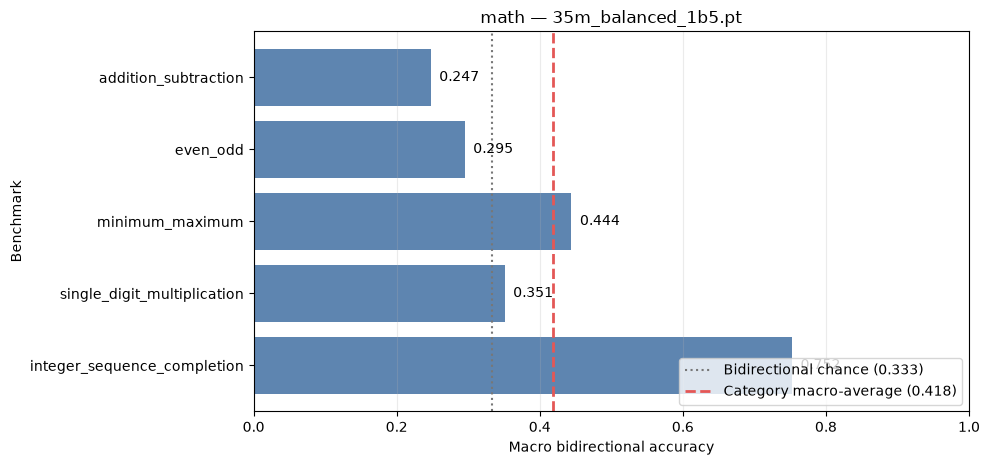

In [10]:
def plot_category_scores(result: dict[str, Any]):
    individual_scores = result["individual_scores"]
    names = list(individual_scores)
    scores = [individual_scores[name] for name in names]
    category_average = result["macro_average"]

    fig_height = max(3.5, 0.65 * len(names) + 1.5)
    fig, ax = plt.subplots(figsize=(10, fig_height))
    bars = ax.barh(names, scores, color="#4C78A8", alpha=0.9)

    ax.axvline(
        1 / 3,
        color="#777777",
        linestyle=":",
        linewidth=1.5,
        label="Bidirectional chance (0.333)",
    )
    ax.axvline(
        category_average,
        color="#E45756",
        linestyle="--",
        linewidth=2,
        label=f"Category macro-average ({category_average:.3f})",
    )
    for bar, score in zip(bars, scores, strict=True):
        ax.text(
            min(score + 0.012, 0.97),
            bar.get_y() + bar.get_height() / 2,
            f"{score:.3f}",
            va="center",
            ha="left" if score < 0.94 else "right",
        )

    ax.set_xlim(0, 1)
    ax.set_xlabel("Macro bidirectional accuracy")
    ax.set_ylabel("Benchmark")
    ax.set_title(
        f"{result['category']} — {Path(result['checkpoint']).name}"
    )
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()
    return fig, ax


_ = plot_category_scores(evaluation_result)

In [11]:
def load_saved_category_results(
    model_checkpoint: str | Path,
    categories: list[str] | None = None,
) -> dict[str, dict[str, Any]]:
    checkpoint = resolve_input_path(model_checkpoint)
    selected_categories = sorted(categories or benchmarks)
    results: dict[str, dict[str, Any]] = {}
    missing: list[Path] = []

    for category in selected_categories:
        score_dir = BENCHMARKS_DIR / "scores" / category / checkpoint.stem
        benchmark_summaries: list[dict[str, Any]] = []
        reports: dict[str, dict[str, Any]] = {}
        for benchmark_path in benchmarks[category]:
            report_path = score_dir / f"{benchmark_path.stem}-scores.json"
            if not report_path.is_file():
                missing.append(report_path)
                continue
            with report_path.open(encoding="utf-8") as file:
                report = json.load(file)
            benchmark_id = report["benchmark_id"]
            reports[benchmark_id] = report
            benchmark_summaries.append(
                {
                    "benchmark_id": benchmark_id,
                    "benchmark_path": str(benchmark_path.resolve()),
                    "report_path": str(report_path),
                    "set_count": len(report["sets"]),
                    "scored_context_target_pairs": sum(
                        len(item["members"]) ** 2 for item in report["sets"]
                    ),
                    "metrics": report["metrics"],
                }
            )

        if len(benchmark_summaries) != len(benchmarks[category]):
            continue
        available_metric_keys = [
            key
            for key in METRIC_KEYS
            if all(key in item["metrics"] for item in benchmark_summaries)
        ]
        category_metrics = {
            key: sum(item["metrics"][key] for item in benchmark_summaries)
            / len(benchmark_summaries)
            for key in available_metric_keys
        }
        individual_scores = {
            item["benchmark_id"]: item["metrics"]["macro_bidirectional_accuracy"]
            for item in benchmark_summaries
        }
        total_bidirectional_wins = sum(
            item["metrics"]["bidirectional_wins"]
            for item in benchmark_summaries
        )
        total_bidirectional_comparisons = sum(
            item["metrics"]["bidirectional_comparisons"]
            for item in benchmark_summaries
        )
        first_report = next(iter(reports.values()))
        results[category] = {
            "category": category,
            "checkpoint": first_report["checkpoint"],
            "tokenizer": first_report["tokenizer"],
            "device": first_report["device"],
            "primary_metric": "macro_bidirectional_accuracy",
            "individual_scores": individual_scores,
            "macro_average": sum(individual_scores.values())
            / len(individual_scores),
            "category_macro_metrics": category_metrics,
            "category_micro_bidirectional_accuracy": (
                total_bidirectional_wins / total_bidirectional_comparisons
            ),
            "benchmarks": benchmark_summaries,
            "reports": reports,
        }

    if missing:
        raise FileNotFoundError(
            "Missing benchmark score reports:\n"
            + "\n".join(str(path) for path in missing)
        )
    return results


def plot_category_averages(
    results_by_category: dict[str, dict[str, Any]],
    *,
    metric: str = "macro_bidirectional_accuracy",
):
    if not results_by_category:
        raise ValueError("results_by_category must not be empty")

    categories = sorted(results_by_category)
    score_groups: list[list[float]] = []
    for category in categories:
        result = results_by_category[category]
        scores = [item["metrics"][metric] for item in result["benchmarks"]]
        if not scores:
            raise ValueError(f"Category {category!r} has no benchmark scores")
        score_groups.append(scores)

    averages = [sum(scores) / len(scores) for scores in score_groups]
    minima = [min(scores) for scores in score_groups]
    maxima = [max(scores) for scores in score_groups]
    lower_ranges = [average - minimum for average, minimum in zip(averages, minima, strict=True)]
    upper_ranges = [maximum - average for average, maximum in zip(averages, maxima, strict=True)]
    positions = list(range(len(categories)))

    fig_width = max(9, 1.6 * len(categories))
    fig, ax = plt.subplots(figsize=(fig_width, 6))
    bars = ax.bar(positions, averages, color="#4C78A8", alpha=0.9)
    ax.errorbar(
        positions,
        averages,
        yerr=[lower_ranges, upper_ranges],
        fmt="none",
        ecolor="#222222",
        elinewidth=1.8,
        capsize=7,
        capthick=1.8,
    )

    for position, bar, average, minimum, maximum in zip(
        positions, bars, averages, minima, maxima, strict=True
    ):
        ax.text(
            position,
            average / 2,
            f"avg\n{average:.3f}",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
        )
        ax.annotate(
            f"max {maximum:.3f}",
            (position, maximum),
            xytext=(0, -5 if maximum > 0.94 else 5),
            textcoords="offset points",
            ha="center",
            va="top" if maximum > 0.94 else "bottom",
        )
        ax.annotate(
            f"min {minimum:.3f}",
            (position, minimum),
            xytext=(0, 5 if minimum < 0.06 else -5),
            textcoords="offset points",
            ha="center",
            va="bottom" if minimum < 0.06 else "top",
        )

    chance_level = 1 / 3 if "bidirectional" in metric else 0.5
    chance_label = (
        "Bidirectional chance (0.333)"
        if "bidirectional" in metric
        else "Pairwise chance (0.50)"
    )
    ax.axhline(
        chance_level,
        color="#777777",
        linestyle=":",
        linewidth=1.5,
        label=chance_label,
    )
    ax.set_ylim(0, 1)
    ax.set_xticks(positions, categories, rotation=25, ha="right")
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_title("Average benchmark accuracy by category")
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)
    ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()
    return fig, ax


def score_all_categories(model_checkpoint: Path, tokenizer: Path, benches: dict[str, list[Path]]):
    print(f"Scoring {model_checkpoint}")
    cat_results = {}
    for c in benches:
        cat_results[c] = evaluate_full_category(
            model_checkpoint,
            tokenizer,
            benches,
            c,
            batch_size=BATCH_SIZE,
            requested_device=DEVICE,
            save_reports=SAVE_DETAILED_REPORTS,
        )
    _ = plot_category_averages(cat_results)

Scoring ../../models/35m_balanced_1b5.pt


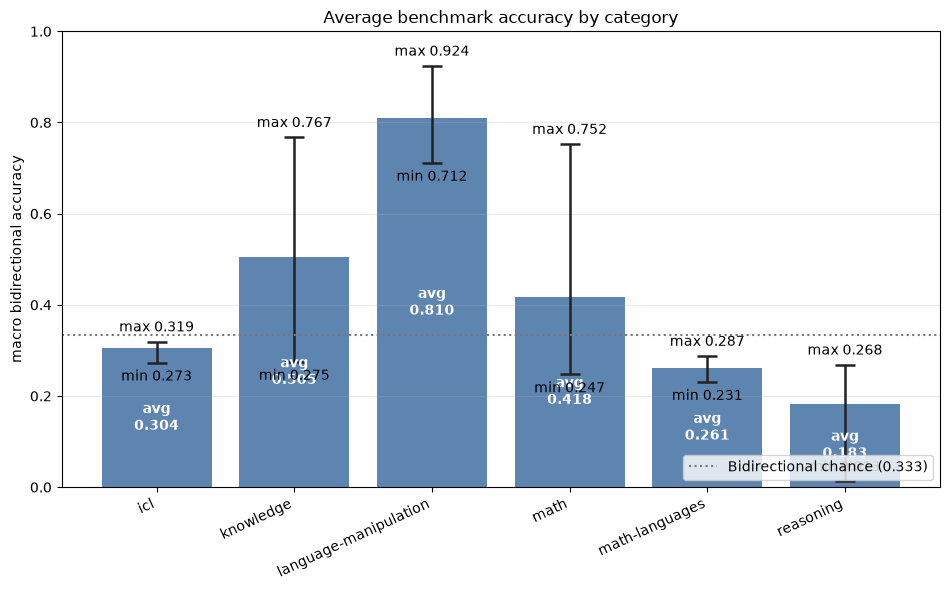

Scoring ../../models/35m_balanced_1b.pt


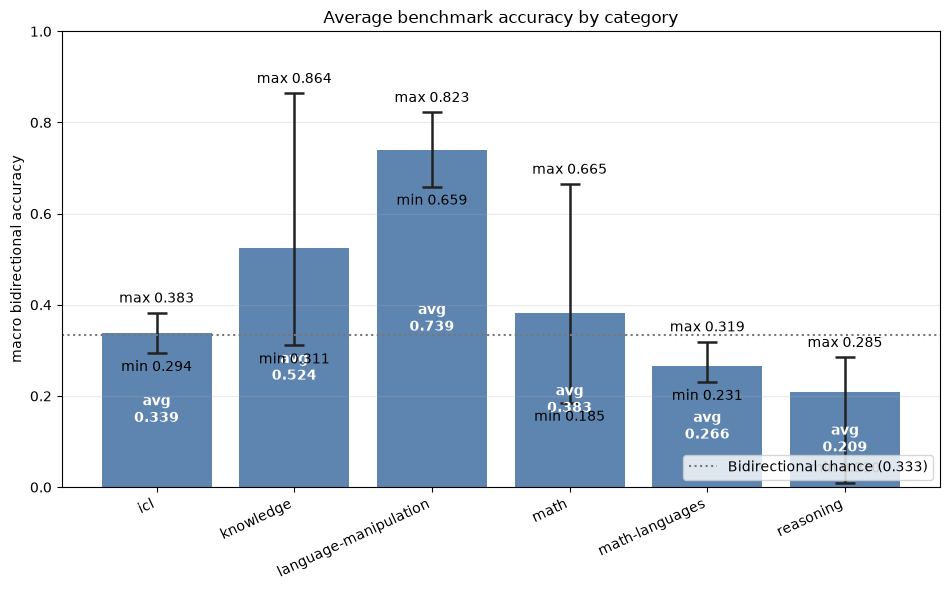

Scoring ../../models/35m_16k_muon_4b.pt


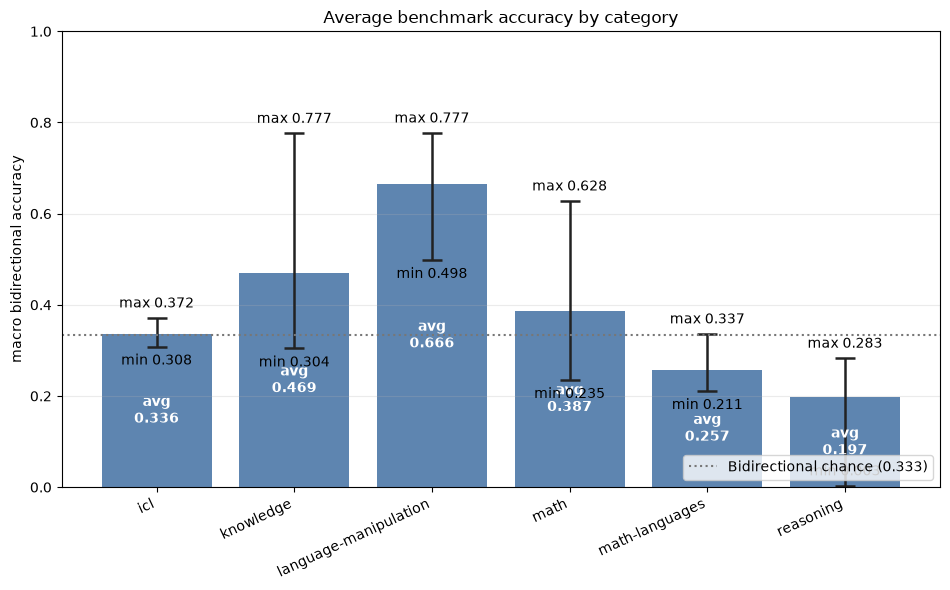

In [12]:
models_toks = [(MODEL_CHECKPOINT, TOKENIZER), ("../../models/35m_balanced_1b.pt", "../../src/tokenizer/production_16k/tokenizer.model"), ("../../models/35m_16k_muon_4b.pt", "../../src/tokenizer/16k/tokenizer.model")]

for m, t in models_toks:
    score_all_categories(m, t, benchmarks)

In [13]:
def compare_category_models(models: list[tuple[str, str]], benches: dict[str, list[Path]], category: str):
    results = []
    for m, t in models:
        results.append(evaluate_full_category(
            m,
            t,
            benches,
            category,
            batch_size=BATCH_SIZE,
            requested_device=DEVICE,
            save_reports=SAVE_DETAILED_REPORTS,
        ))
    print(f"Results for category {category}")
    for i, mt in enumerate(models):
        m, _ = mt
        print(f"Model {m}: ")
        print_category_table(results[i])

compare_category_models(models_toks, benchmarks, "reasoning")

Results for category reasoning
Model ../../models/35m_balanced_1b5.pt: 


| Benchmark | Sets | Bidirectional (macro) | Bidirectional (micro) | Context | Target | Perfect both |
|---|---:|---:|---:|---:|---:|---:|
| reasoning_constraint_elimination | 100 | 1.25% | 1.25% | 1.33% | 27.33% | 0.00% |
| reasoning_transitive_ordering | 100 | 21.25% | 21.25% | 44.25% | 48.67% | 0.00% |
| reasoning_rule_chaining | 100 | 26.83% | 26.83% | 51.67% | 49.58% | 0.00% |
| reasoning_spatial_ordering | 100 | 18.92% | 18.92% | 46.00% | 48.17% | 0.00% |
| reasoning_temporal_ordering | 100 | 23.33% | 23.33% | 48.92% | 50.25% | 0.00% |
| **Category macro-average** | 500 | **18.32%** | 18.32% | 38.43% | 44.80% | 0.00% |

Model ../../models/35m_balanced_1b.pt: 


| Benchmark | Sets | Bidirectional (macro) | Bidirectional (micro) | Context | Target | Perfect both |
|---|---:|---:|---:|---:|---:|---:|
| reasoning_constraint_elimination | 100 | 1.00% | 1.00% | 1.08% | 26.50% | 0.00% |
| reasoning_transitive_ordering | 100 | 27.00% | 27.00% | 48.50% | 50.33% | 0.00% |
| reasoning_rule_chaining | 100 | 24.00% | 24.00% | 50.75% | 49.50% | 0.00% |
| reasoning_spatial_ordering | 100 | 28.50% | 28.50% | 57.08% | 50.92% | 0.00% |
| reasoning_temporal_ordering | 100 | 24.25% | 24.25% | 50.17% | 49.75% | 0.00% |
| **Category macro-average** | 500 | **20.95%** | 20.95% | 41.52% | 45.40% | 0.00% |

Model ../../models/35m_16k_muon_4b.pt: 


| Benchmark | Sets | Bidirectional (macro) | Bidirectional (micro) | Context | Target | Perfect both |
|---|---:|---:|---:|---:|---:|---:|
| reasoning_constraint_elimination | 100 | 0.33% | 0.33% | 0.58% | 14.83% | 0.00% |
| reasoning_transitive_ordering | 100 | 22.58% | 22.58% | 50.33% | 49.17% | 0.00% |
| reasoning_rule_chaining | 100 | 23.17% | 23.17% | 50.17% | 49.25% | 0.00% |
| reasoning_spatial_ordering | 100 | 28.33% | 28.33% | 57.67% | 50.00% | 0.00% |
| reasoning_temporal_ordering | 100 | 24.08% | 24.08% | 50.17% | 49.00% | 0.00% |
| **Category macro-average** | 500 | **19.70%** | 19.70% | 41.78% | 42.45% | 0.00% |

Scoring ../../models/35m_balanced_300m.pt


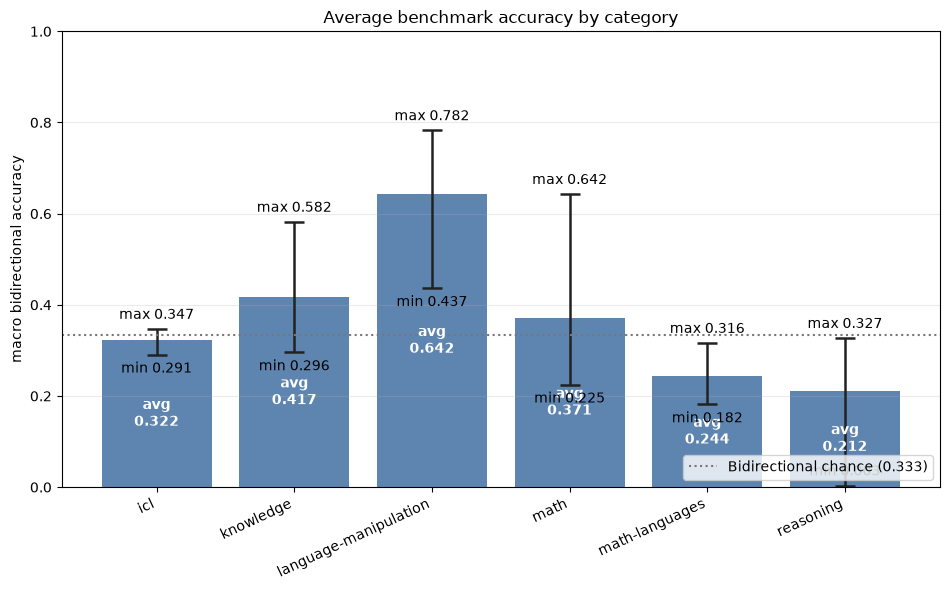

Scoring ../../models/35m_knowledge_300m.pt


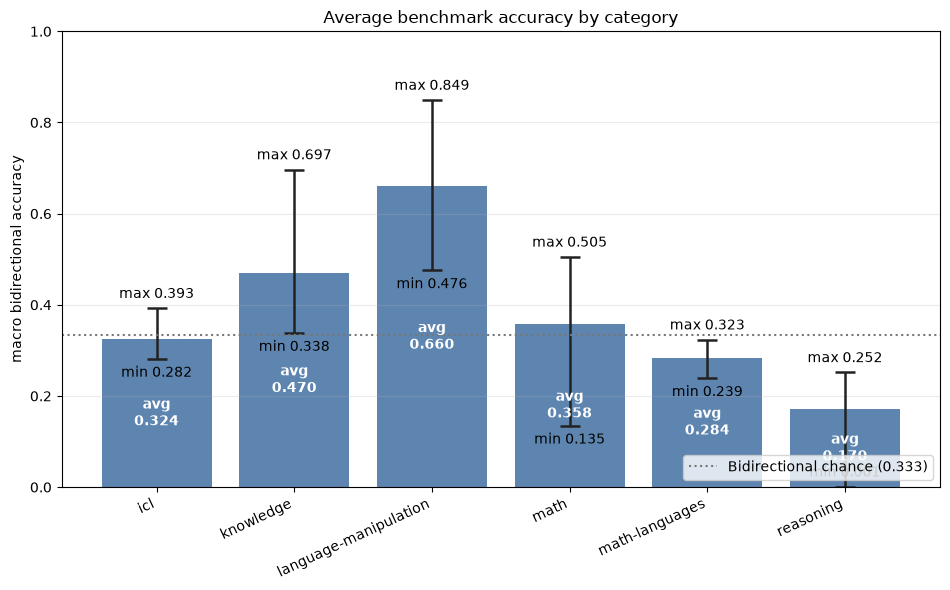

Scoring ../../models/35m_web_300m.pt


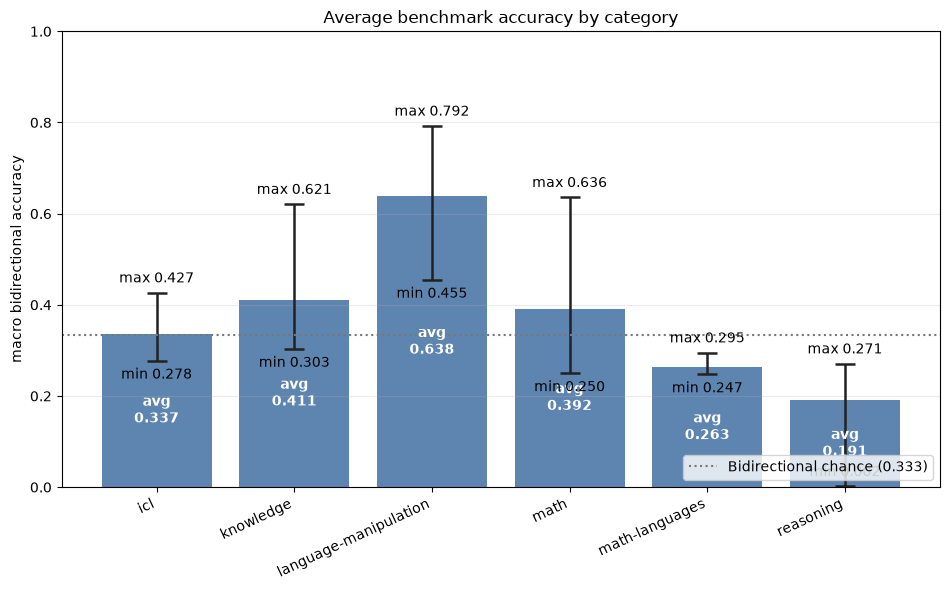

In [14]:
score_all_categories("../../models/35m_balanced_300m.pt", "../../src/tokenizer/production_16k/tokenizer.model", benchmarks)
score_all_categories("../../models/35m_knowledge_300m.pt", "../../src/tokenizer/production_16k/tokenizer.model", benchmarks)
score_all_categories("../../models/35m_web_300m.pt", "../../src/tokenizer/production_16k/tokenizer.model", benchmarks)

In [15]:
mt = [("../../models/35m_balanced_300m.pt", "../../src/tokenizer/production_16k/tokenizer.model"), ("../../models/35m_knowledge_300m.pt", "../../src/tokenizer/production_16k/tokenizer.model"), ("../../models/35m_web_300m.pt", "../../src/tokenizer/production_16k/tokenizer.model")]
compare_category_models(mt, benchmarks, "reasoning")

Results for category reasoning
Model ../../models/35m_balanced_300m.pt: 


| Benchmark | Sets | Bidirectional (macro) | Bidirectional (micro) | Context | Target | Perfect both |
|---|---:|---:|---:|---:|---:|---:|
| reasoning_constraint_elimination | 100 | 0.33% | 0.33% | 0.33% | 16.92% | 0.00% |
| reasoning_transitive_ordering | 100 | 19.58% | 19.58% | 52.92% | 47.50% | 0.00% |
| reasoning_rule_chaining | 100 | 25.92% | 25.92% | 49.58% | 49.58% | 0.00% |
| reasoning_spatial_ordering | 100 | 32.67% | 32.67% | 59.75% | 54.33% | 0.00% |
| reasoning_temporal_ordering | 100 | 27.42% | 27.42% | 53.42% | 50.08% | 0.00% |
| **Category macro-average** | 500 | **21.18%** | 21.18% | 43.20% | 43.68% | 0.00% |

Model ../../models/35m_knowledge_300m.pt: 


| Benchmark | Sets | Bidirectional (macro) | Bidirectional (micro) | Context | Target | Perfect both |
|---|---:|---:|---:|---:|---:|---:|
| reasoning_constraint_elimination | 100 | 0.08% | 0.08% | 0.33% | 14.25% | 0.00% |
| reasoning_transitive_ordering | 100 | 12.33% | 12.33% | 49.83% | 46.83% | 0.00% |
| reasoning_rule_chaining | 100 | 25.17% | 25.17% | 49.08% | 49.83% | 0.00% |
| reasoning_spatial_ordering | 100 | 24.42% | 24.42% | 49.83% | 48.92% | 0.00% |
| reasoning_temporal_ordering | 100 | 23.17% | 23.17% | 48.50% | 49.33% | 0.00% |
| **Category macro-average** | 500 | **17.03%** | 17.03% | 39.52% | 41.83% | 0.00% |

Model ../../models/35m_web_300m.pt: 


| Benchmark | Sets | Bidirectional (macro) | Bidirectional (micro) | Context | Target | Perfect both |
|---|---:|---:|---:|---:|---:|---:|
| reasoning_constraint_elimination | 100 | 0.17% | 0.17% | 0.17% | 20.67% | 0.00% |
| reasoning_transitive_ordering | 100 | 19.67% | 19.67% | 53.83% | 46.58% | 0.00% |
| reasoning_rule_chaining | 100 | 25.42% | 25.42% | 50.25% | 49.58% | 0.00% |
| reasoning_spatial_ordering | 100 | 23.08% | 23.08% | 49.42% | 49.08% | 0.00% |
| reasoning_temporal_ordering | 100 | 27.08% | 27.08% | 47.67% | 49.75% | 0.00% |
| **Category macro-average** | 500 | **19.08%** | 19.08% | 40.27% | 43.13% | 0.00% |